Загрузка набора поведенческих данных,связывающих использование смартфонов подростками с уровнем зависимости и состоянием здоровья.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


Загрузка данных и проверка количества пропущенных значений

In [3]:
data = pd.read_csv('teen_phone_addiction_dataset.csv')
print(data.isnull().sum())

ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64


Пропущенных значений нет

In [4]:
from IPython.display import display
display(data.head(5))

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


Проверим количество уникальных значений в столбце School_Grade

In [18]:
value_counts_school_Grade = data['School_Grade'].value_counts()
print(value_counts_school_Grade)
print(data['School_Grade'].dtype)

School_Grade
12th    529
9th     526
7th     497
10th    487
8th     482
11th    479
Name: count, dtype: int64
object


Данные в столбце представлены как категориальные, но означают класс обучения,есть смысл преобразовать их в числовые

Проверка типа данных остальных столбцов

In [21]:
display(data.dtypes)

ID                          int64
Name                       object
Age                         int64
Gender                     object
Location                   object
School_Grade               object
Daily_Usage_Hours         float64
Sleep_Hours               float64
Academic_Performance        int64
Social_Interactions         int64
Exercise_Hours            float64
Anxiety_Level               int64
Depression_Level            int64
Self_Esteem                 int64
Parental_Control            int64
Screen_Time_Before_Bed    float64
Phone_Checks_Per_Day        int64
Apps_Used_Daily             int64
Time_on_Social_Media      float64
Time_on_Gaming            float64
Time_on_Education         float64
Phone_Usage_Purpose        object
Family_Communication        int64
Weekend_Usage_Hours       float64
Addiction_Level           float64
grade_numeric               int64
Gender_encoded              int64
dtype: object

Проверка наличия выбросов

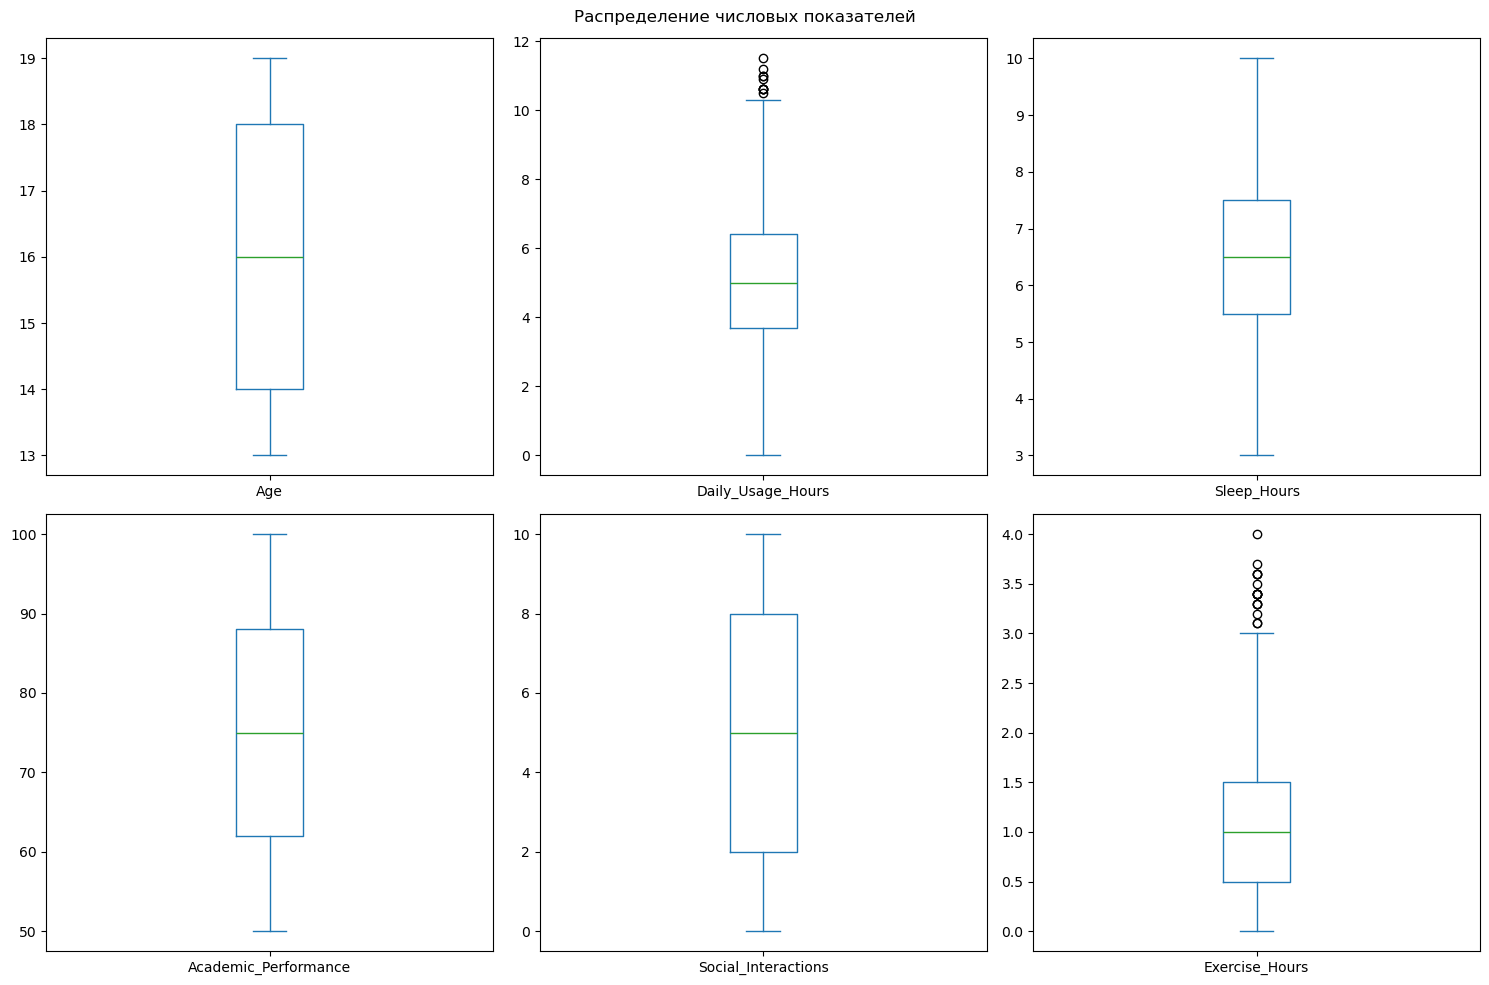

In [8]:
# Выбор столбцов для анализа
numeric_columns = ['Age', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 
                  'Social_Interactions', 'Exercise_Hours']
['Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education',
'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level', '' ]


# Построение boxplot для всех выбранных столбцов
data[numeric_columns].plot(kind='box', 
                          subplots=True, 
                          layout=(2, 3), 
                          figsize=(15, 10),
                          sharey=False)  # sharey=False если масштабы разные
plt.suptitle('Распределение числовых показателей')
plt.tight_layout()
plt.show()

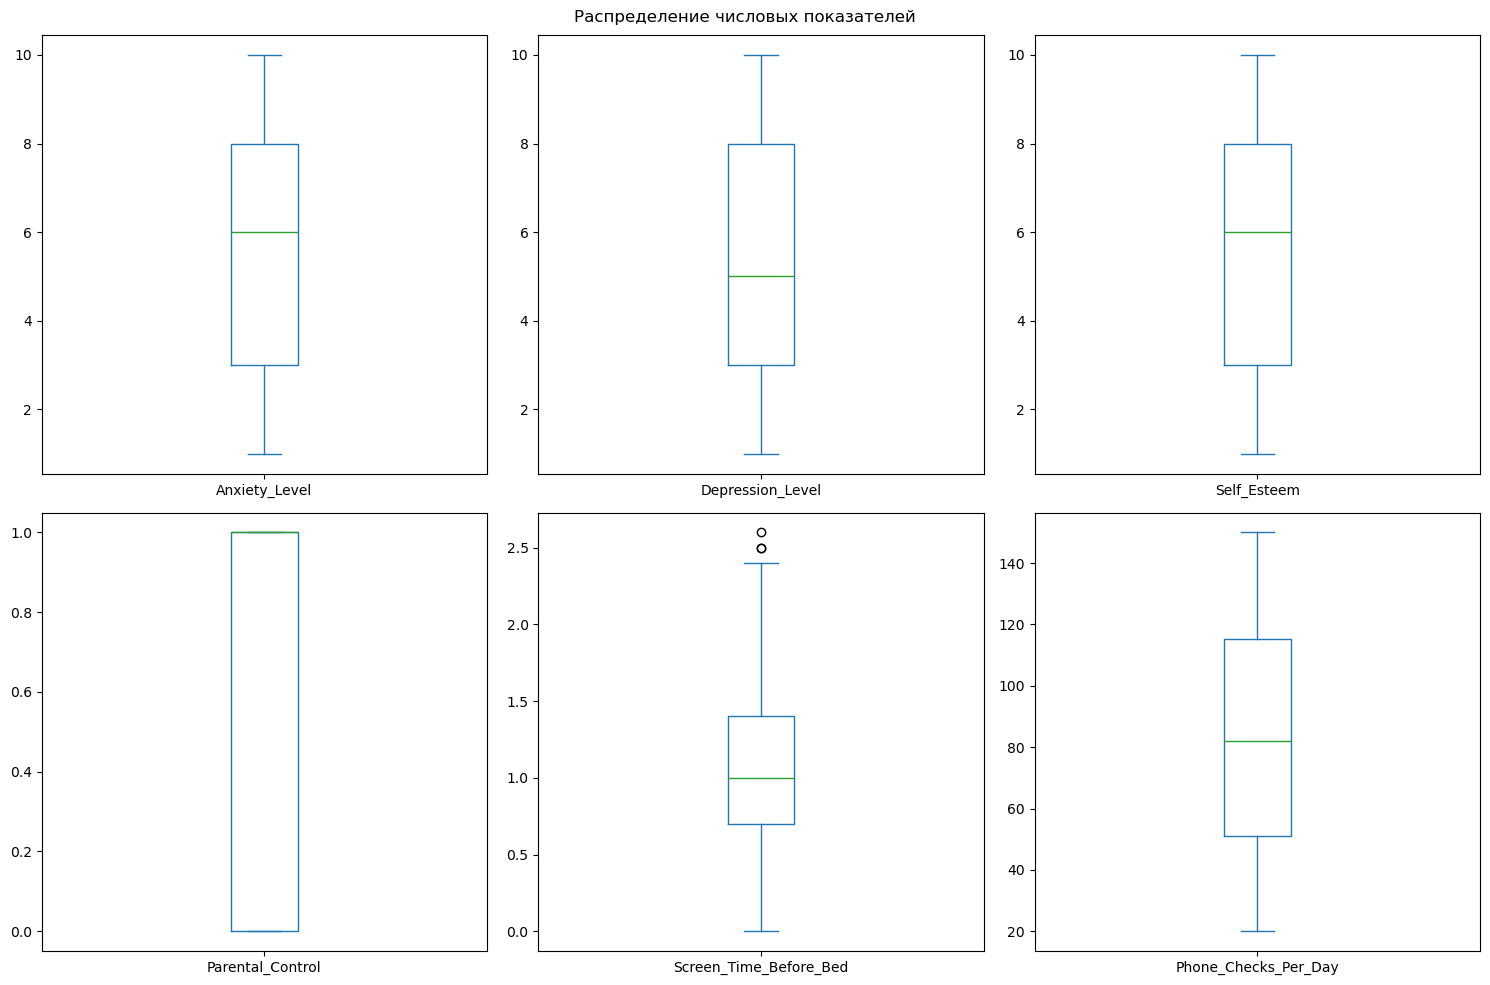

In [9]:
numeric_columns_two = ['Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control',
                   'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day']
# Построение boxplot для всех выбранных столбцов
data[numeric_columns_two].plot(kind='box', 
                          subplots=True, 
                          layout=(2, 3), 
                          figsize=(15, 10),
                          sharey=False)  # sharey=False если масштабы разные
plt.suptitle('Распределение числовых показателей')
plt.tight_layout()
plt.show()

По данным boxplot выбросы есть у данных в столбцах: Daily_Usage_Hours, Exercise_Hours, Screen_Time_Before_Bed, Weekend_Usage_Hours,Addiction_Level, - но их нельзя отнести к типичным выбросам, все они находятся в диапазоне адекватных значений,которые вполне могут быть. Поэтому никаких действий с ними предпринимать не нужно.


Преобразуем остальные категориальные признаки в числовые 

Проверим какие уникальные значения есть в столбце Gender

In [19]:
value_counts_Gender = data['Gender'].value_counts()
print(value_counts_Gender)

Gender
Male      1016
Female    1007
Other      977
Name: count, dtype: int64


Используем кодировку для пола

In [16]:
data['Gender_encoded'] = data['Gender'].map({'Male': 0, 'Female': 1, 'Other':3})

Проверим уникальные значения в столбце Location

In [20]:
value_counts_Location = data['Location'].value_counts()
print(value_counts_Location)

Location
North Michael        6
Lake Michael         5
Lake James           4
North Jennifer       4
South Michael        4
                    ..
Paulstad             1
Port Nicholasberg    1
Port Jonathanside    1
Margaretmouth        1
Theodorefort         1
Name: count, Length: 2726, dtype: int64


Данные разнообразны, применить One-Hot Encoding не получится.

In [ ]:
Проверим уникальные значения в столбце Phone_Usage_Purpose

In [22]:
value_counts_Phone_Usage_Purpose = data['Phone_Usage_Purpose'].value_counts()
print(value_counts_Phone_Usage_Purpose)

Phone_Usage_Purpose
Browsing        627
Other           622
Education       602
Social Media    575
Gaming          574
Name: count, dtype: int64
